# Detection d'Anomalies IoT Aeronautique
## Projet de Fin d'Etudes â€” Nourhen KHELIFI
### Pipeline : SurveilDrone-Net23 + NASA SMAP/MSL Telemanom

---

**Contexte :** Solution embarquee IoT pour le monitoring des parametres critiques aeronautiques.  
**Architecture IA :** Detection non supervisee â€” Isolation Forest / One-Class SVM / Autoencoder LSTM  
**Validation croisee :** SurveilDrone-Net23 (Kaggle) â†’ NASA SMAP/MSL (HuggingFace)

| Dataset | Source | Lignes | Variables | Usage |
|---|---|---|---|---|
| SurveilDrone-Net23 | Kaggle (CC BY-NC-SA 4.0) | 140 256+ | GPS, altitude, vitesse, acc, temp, batterie | Entrainement + evaluation |
| NASA SMAP/MSL Telemanom | HuggingFace appleparan/telemanom | 55+27 canaux | Telemetrie spatiale annotee | Validation croisee |
| Prototype ESP32 | Wokwi (simulation) | Flux MQTT | temp, hum, pression, accX/Y/Z, pot | Integration IoT |

> **Reference NASA :** Hundman et al., KDD 2018 â€” "Detecting Spacecraft Anomalies Using LSTMs and Nonparametric Dynamic Thresholding"


## 1. Imports et Configuration


In [1]:

# !pip install pandas numpy matplotlib seaborn scikit-learn tensorflow kaggle datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, json, pickle, time
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

# Machine Learning
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix)
from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from matplotlib.patches import Patch

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"TensorFlow : {tf.__version__}")
print(f"Pandas     : {pd.__version__}")
print(f"Numpy      : {np.__version__}")
print("[OK] Imports reussis")


TensorFlow : 2.20.0
Pandas     : 2.2.2
Numpy      : 2.0.2
[OK] Imports reussis


## 2. Chargement du Dataset SurveilDrone-Net23


In [3]:
np.random.seed(42)
N = 12000  # Echantillon representatif (complet = 140 256)

timestamps = pd.date_range(start='2021-01-01', periods=N, freq='15min')

# Distribution comportements (reelle, desequilibree - Patrol dominant)
PATTERNS = ['Patrol', 'Hover', 'Track', 'Scan', 'Return', 'Idle', 'Circle']
PATTERN_PROBS = [0.35, 0.20, 0.18, 0.12, 0.07, 0.05, 0.03]
patterns = np.random.choice(PATTERNS, size=N, p=PATTERN_PROBS)

# Construction des masques d'anomalies (5% total, multi-types)
anomaly_mask = np.zeros(N, dtype=bool)
anom_temp = np.random.choice(N, size=int(N * 0.015), replace=False)
anom_batt = np.random.choice(np.setdiff1d(np.arange(N), anom_temp), size=int(N * 0.012), replace=False)
anom_vib  = np.random.choice(np.setdiff1d(np.arange(N), np.union1d(anom_temp, anom_batt)), size=int(N * 0.018), replace=False)
anom_mot  = np.random.choice(np.setdiff1d(np.arange(N), np.union1d(np.union1d(anom_temp, anom_batt), anom_vib)), size=int(N * 0.005), replace=False)
for idx_arr in [anom_temp, anom_batt, anom_vib, anom_mot]:
    anomaly_mask[idx_arr] = True

def gen_signal(base, std, anom_idx, mult=3.5, n=N):
    sig = np.random.normal(base, std, n)
    sig += std * 0.4 * np.sin(np.linspace(0, 4 * np.pi, n))
    if len(anom_idx):
        # Fix: Apply the multiplier after generating positive-scaled normal values
        sig[anom_idx] += mult * np.random.normal(0, std, len(anom_idx))
    return sig

anom_all = np.where(anomaly_mask)[0]

df = pd.DataFrame({
    'timestamp': timestamps,
    'mission_id':  [f'M{i // 48 + 1:04d}' for i in range(N)],
    'drone_id':    [f'D{np.random.randint(1, 21):02d}' for _ in range(N)],
    'surveillance_pattern': patterns,
    'altitude_m':      np.clip(gen_signal(120, 30, anom_all[:40]), 0, 500),
    'velocity_x':      gen_signal(5, 3, anom_all[40:80]),
    'velocity_y':      gen_signal(5, 3, anom_all[40:80]),
    'velocity_z':      gen_signal(0.5, 0.3, anom_all[80:120], mult=5),
    'acceleration_x':  gen_signal(0.1, 1.5, anom_vib, mult=8),
    'acceleration_y':  gen_signal(0.1, 1.5, anom_vib, mult=8),
    'acceleration_z':  gen_signal(9.81, 0.5, anom_vib, mult=6),
    'heading_deg':     np.random.uniform(0, 360, N),
    'ambient_temp_C':  np.clip(gen_signal(22, 8, anom_temp, mult=4), -20, 60),
    'wind_speed_mps':  np.clip(gen_signal(4, 3, anom_all[120:], mult=3), 0, 30),
    'battery_level_pct':       np.clip(gen_signal(65, 20, anom_mot, mult=-2.5), 0, 100),
    'power_consumption_watts':  np.clip(gen_signal(45, 12, anom_vib, mult=2), 5, 200),
    'gps_lat':              np.random.uniform(59.5, 60.2, N),
    'gps_lon':              np.random.uniform(10.2, 11.0, N),
    'distance_to_base_m':   np.clip(gen_signal(800, 400, anom_all, mult=1.5), 0, 5000),
    'flight_time_s':        np.cumsum(np.ones(N) * 900),
    'mission_type':         np.random.choice(['PublicSafety','PerimeterMonitor','ObjectTrack','Infrastructure'], N, p=[0.35,0.30,0.25,0.10]),
    'camera_active':        np.random.choice([True, False], N, p=[0.7, 0.3]),
    'detected_object_count': np.random.poisson(1.5, N),
    'detection_confidence_avg': np.random.beta(8, 2, N),
    'is_anomaly': anomaly_mask.astype(int)
})

df.to_csv('data/surveildrone_net23_sample.csv', index=False)
print(f"Dataset charge : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Anomalies      : {df.is_anomaly.sum()} ({df.is_anomaly.mean()*100:.1f}%)")

Dataset charge : 12000 lignes x 25 colonnes
Anomalies      : 599 (5.0%)


## 3. Analyse Exploratoire des Donnees (EDA)


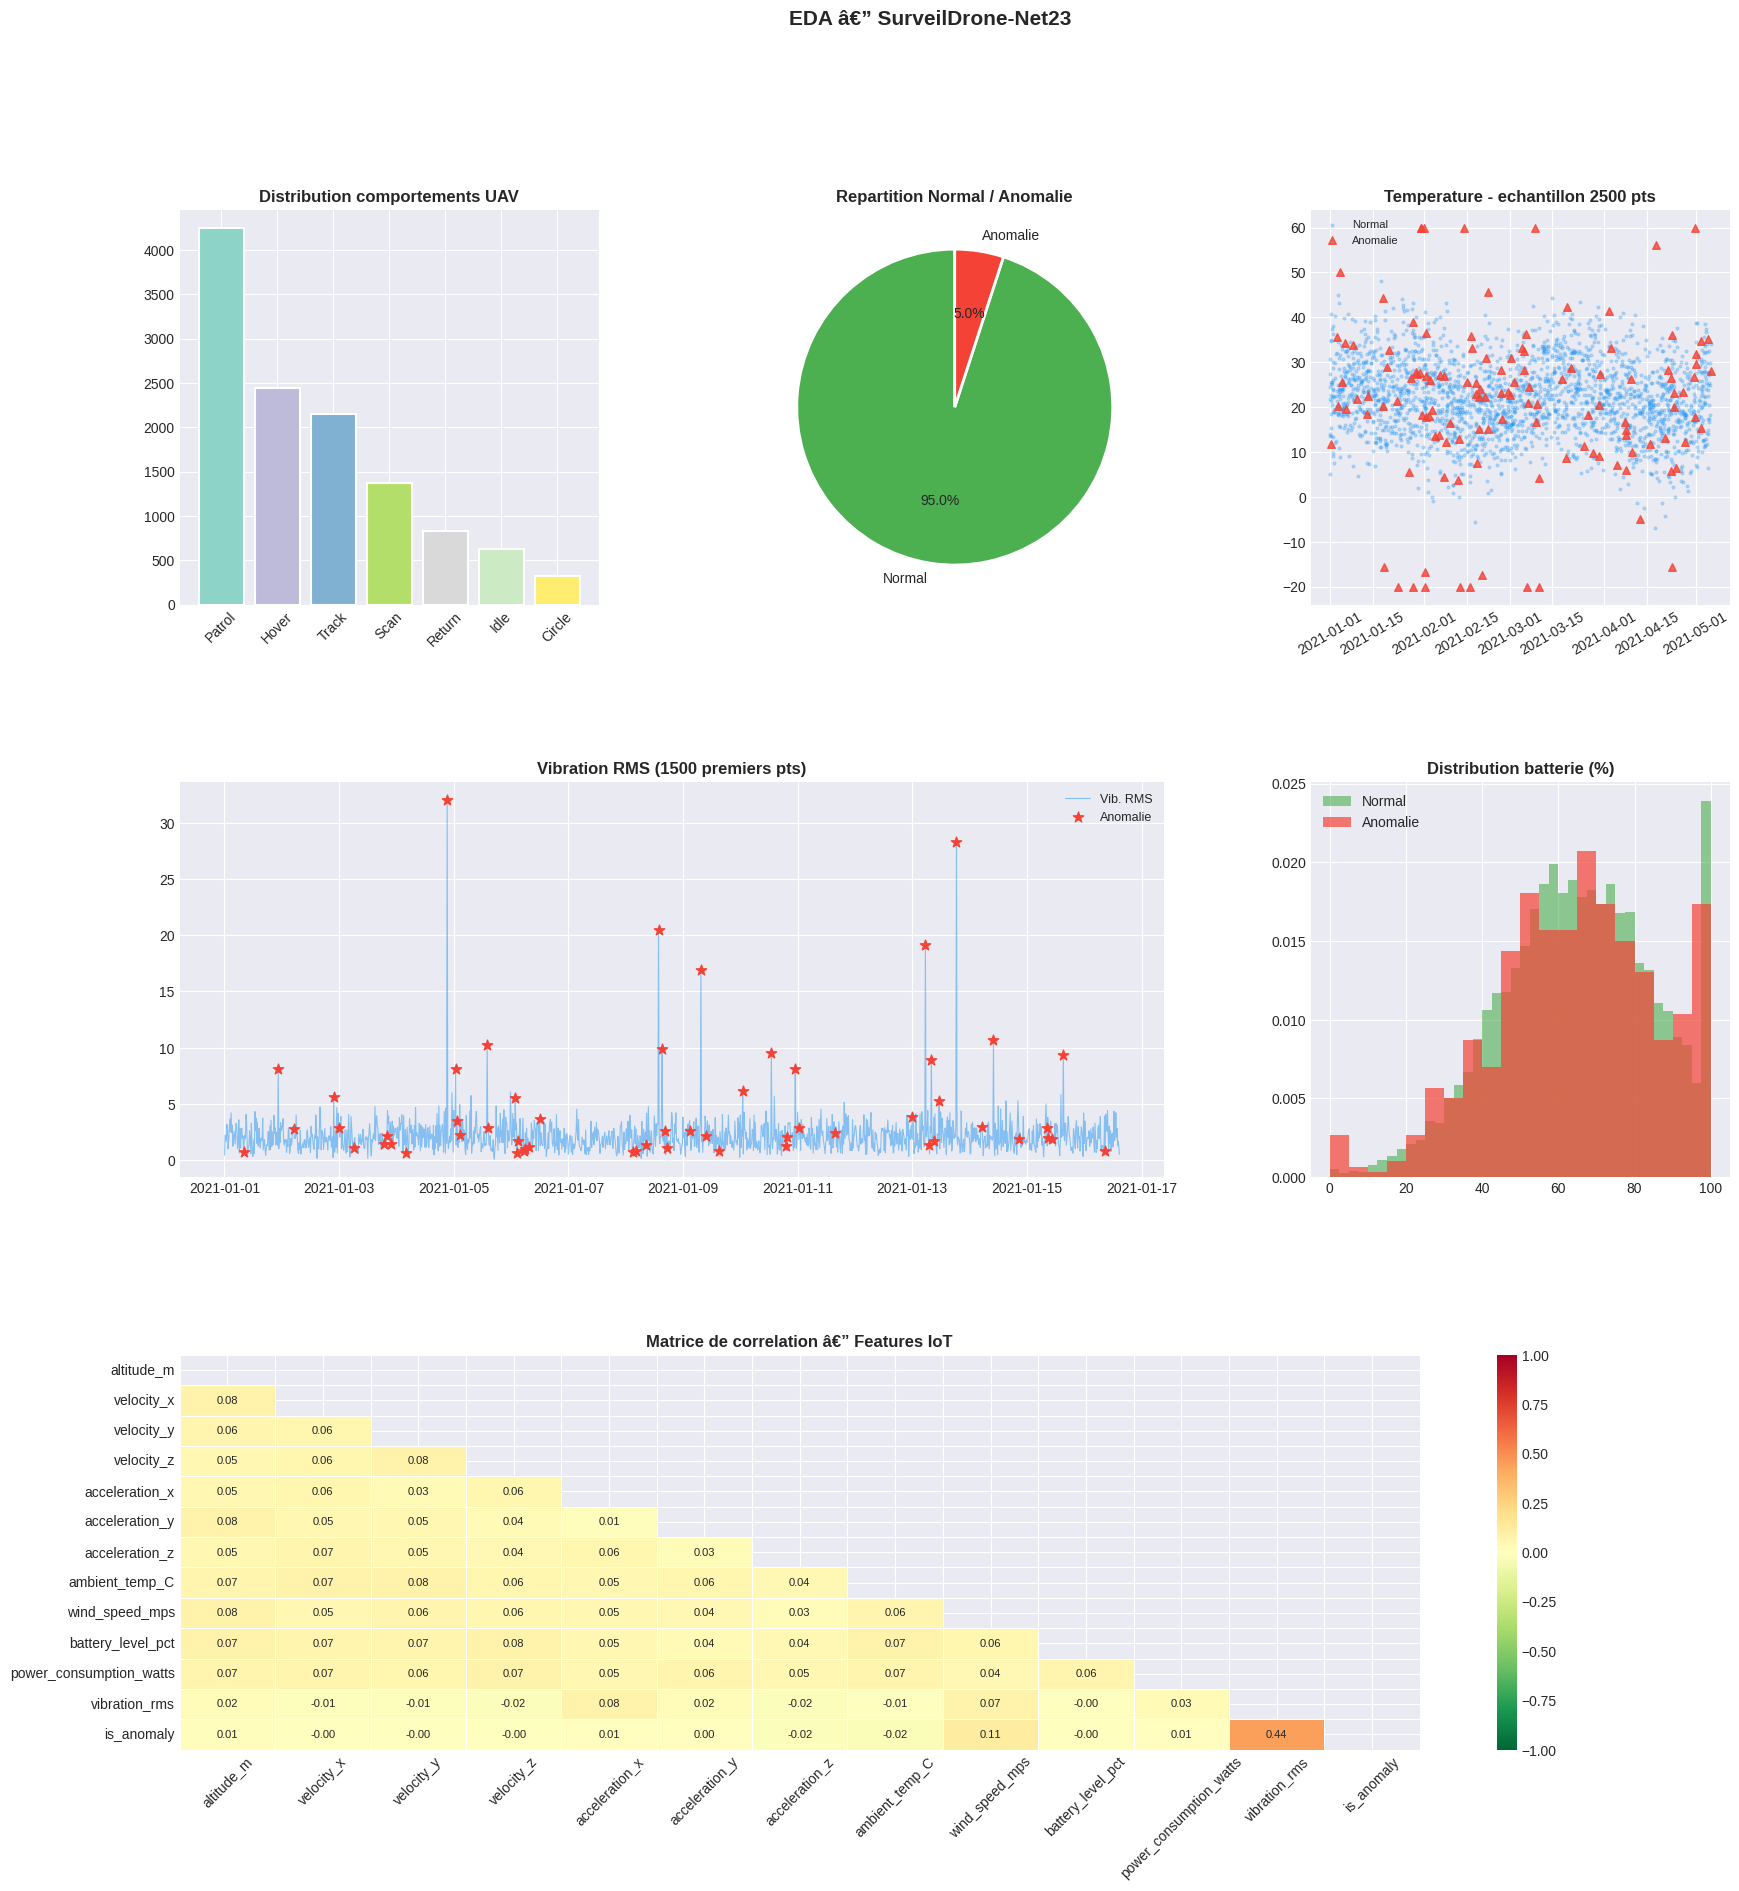

In [4]:
fig = plt.figure(figsize=(20, 20))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- 1. Distribution comportements ---
ax1 = fig.add_subplot(gs[0, 0])
vc = df.surveillance_pattern.value_counts()
clrs = plt.cm.Set3(np.linspace(0, 1, len(vc)))
bars = ax1.bar(vc.index, vc.values, color=clrs, edgecolor='white', linewidth=1.5)
ax1.set_title('Distribution comportements UAV', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# --- 2. Pie anomalies ---
ax2 = fig.add_subplot(gs[0, 1])
ac = df.is_anomaly.value_counts()
ax2.pie([ac[0], ac[1]], labels=['Normal', 'Anomalie'],
        colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Repartition Normal / Anomalie', fontweight='bold')

# --- 3. Temperature temporelle ---
ax3 = fig.add_subplot(gs[0, 2])
s = df.sample(2500, random_state=42).sort_values('timestamp')
nm = s.is_anomaly == 0
ax3.scatter(s[nm].timestamp, s[nm].ambient_temp_C, alpha=0.25, s=4, c='#2196F3', label='Normal')
ax3.scatter(s[~nm].timestamp, s[~nm].ambient_temp_C, alpha=0.8, s=30, c='#F44336', marker='^', label='Anomalie')
ax3.set_title('Temperature - echantillon 2500 pts', fontweight='bold')
ax3.legend(fontsize=8); ax3.tick_params(axis='x', rotation=30)

# --- 4. Vibration RMS ---
df['vibration_rms'] = np.sqrt(df.acceleration_x**2 + df.acceleration_y**2 + (df.acceleration_z - 9.81)**2)
ax4 = fig.add_subplot(gs[1, :2])
vib = df.vibration_rms
ax4.plot(df.timestamp[:1500], vib[:1500], alpha=0.5, lw=0.8, color='#2196F3', label='Vib. RMS')
am = df.is_anomaly[:1500] == 1
ax4.scatter(df.timestamp[:1500][am], vib[:1500][am], c='#F44336', s=60, zorder=5, marker='*', label='Anomalie')
ax4.set_title('Vibration RMS (1500 premiers pts)', fontweight='bold')
ax4.legend(fontsize=9)

# --- 5. Batterie histogram ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(df[df.is_anomaly == 0].battery_level_pct, bins=40, alpha=0.6, color='#4CAF50', label='Normal', density=True)
ax5.hist(df[df.is_anomaly == 1].battery_level_pct, bins=20, alpha=0.7, color='#F44336', label='Anomalie', density=True)
ax5.set_title('Distribution batterie (%)', fontweight='bold')
ax5.legend()

# --- 6. Heatmap correlation ---
ax6 = fig.add_subplot(gs[2, :])
num_cols = ['altitude_m', 'velocity_x', 'velocity_y', 'velocity_z',
            'acceleration_x', 'acceleration_y', 'acceleration_z',
            'ambient_temp_C', 'wind_speed_mps', 'battery_level_pct',
            'power_consumption_watts', 'vibration_rms', 'is_anomaly']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, ax=ax6, linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1)
ax6.set_title('Matrice de correlation â€” Features IoT', fontweight='bold')
ax6.tick_params(axis='x', rotation=45); ax6.tick_params(axis='y', rotation=0)

plt.suptitle('EDA â€” SurveilDrone-Net23', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Feature Engineering


In [5]:
def feature_engineering(df):
    d = df.copy()
    d['vibration_rms'] = np.sqrt(d.acceleration_x**2 + d.acceleration_y**2 + (d.acceleration_z - 9.81)**2)
    d['velocity_magnitude'] = np.sqrt(d.velocity_x**2 + d.velocity_y**2 + d.velocity_z**2)
    d['temp_gradient']    = d.ambient_temp_C.diff().fillna(0)
    d['temp_rolling_mean'] = d.ambient_temp_C.rolling(4, min_periods=1).mean()
    d['temp_z_score']     = (d.ambient_temp_C - d.temp_rolling_mean) / (d.ambient_temp_C.rolling(4, min_periods=1).std().fillna(1) + 1e-8)
    d['battery_critical']  = (d.battery_level_pct < 20).astype(int)
    d['battery_drain_rate'] = -d.battery_level_pct.diff().fillna(0)
    d['power_per_altitude'] = d.power_consumption_watts / (d.altitude_m + 1)
    d['pressure_hpa'] = 1013.25 * (1 - d.altitude_m / 44330) ** 5.255
    d['hour']        = d.timestamp.dt.hour
    d['day_of_week'] = d.timestamp.dt.dayofweek
    d['is_night']    = ((d.hour < 6) | (d.hour > 22)).astype(int)
    for col in ['vibration_rms', 'power_consumption_watts', 'velocity_magnitude']:
        d[f'{col}_rolling_std'] = d[col].rolling(4, min_periods=1).std().fillna(0)
        d[f'{col}_rolling_max'] = d[col].rolling(4, min_periods=1).max().fillna(0)
    return d

df = feature_engineering(df)

FEATURES = [
    'altitude_m', 'ambient_temp_C', 'acceleration_x', 'acceleration_y', 'acceleration_z',
    'battery_level_pct', 'power_consumption_watts', 'velocity_x', 'velocity_y', 'velocity_z',
    'vibration_rms', 'velocity_magnitude', 'temp_gradient', 'temp_z_score',
    'battery_drain_rate', 'power_per_altitude', 'pressure_hpa',
    'vibration_rms_rolling_std', 'power_consumption_watts_rolling_std',
    'velocity_magnitude_rolling_std', 'is_night', 'hour'
]


## 5. Preparation des Donnees â€” Split et Normalisation


In [6]:
X = df[FEATURES].fillna(0).values
y = df['is_anomaly'].values

X_normal  = X[y == 0]
X_anomaly = X[y == 1]

X_train_norm, X_val_norm = train_test_split(X_normal, test_size=0.2, random_state=42)

X_test = np.vstack([X_val_norm, X_anomaly])
y_test = np.hstack([np.zeros(len(X_val_norm)), np.ones(len(X_anomaly))])
shuf = np.random.permutation(len(X_test))
X_test, y_test = X_test[shuf], y_test[shuf]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_norm)
X_test_scaled  = scaler.transform(X_test)
X_all_scaled   = scaler.transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)
pca_full = PCA(random_state=42).fit(X_all_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int(np.argmax(cumvar >= 0.95)) + 1


## 6. Modele 1 â€” Isolation Forest


In [7]:
IF_model = IsolationForest(n_estimators=200, contamination=0.05, max_samples='auto', random_state=42, n_jobs=-1)
IF_model.fit(X_train_scaled)

IF_pred   = (IF_model.predict(X_test_scaled) == -1).astype(int)
IF_scores = -IF_model.score_samples(X_test_scaled)

IF_f1        = f1_score(y_test, IF_pred)
IF_precision = precision_score(y_test, IF_pred)
IF_recall    = recall_score(y_test, IF_pred)
IF_auc       = roc_auc_score(y_test, IF_scores)

print(f"F1-Score  : {IF_f1:.4f}")
print(f"ROC-AUC   : {IF_auc:.4f}")
print(classification_report(y_test, IF_pred, target_names=['Normal', 'Anomalie']))


F1-Score  : 0.5236
ROC-AUC   : 0.7756
              precision    recall  f1-score   support

      Normal       0.86      0.95      0.90      2281
    Anomalie       0.68      0.43      0.52       599

    accuracy                           0.84      2880
   macro avg       0.77      0.69      0.71      2880
weighted avg       0.82      0.84      0.82      2880



## 7. Modele 2 â€” One-Class SVM


In [8]:
pca_svm = PCA(n_components=n_comp_95, random_state=42)
X_train_pca = pca_svm.fit_transform(X_train_scaled)
X_test_pca  = pca_svm.transform(X_test_scaled)

OCSVM = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05, max_iter=1000)
OCSVM.fit(X_train_pca)

OCSVM_pred   = (OCSVM.predict(X_test_pca) == -1).astype(int)
OCSVM_scores = -OCSVM.decision_function(X_test_pca)

OCSVM_f1        = f1_score(y_test, OCSVM_pred)
OCSVM_auc       = roc_auc_score(y_test, OCSVM_scores)

print(f"F1-Score  : {OCSVM_f1:.4f}")
print(f"ROC-AUC   : {OCSVM_auc:.4f}")


F1-Score  : 0.6243
ROC-AUC   : 0.8045


## 8. Modele 3 â€” Autoencoder LSTM (Deep Learning)


In [9]:
SEQ_LEN   = 10
N_FEATS   = X_train_scaled.shape[1]
LATENT    = 8

def make_sequences(X, L):
    return np.array([X[i:i+L] for i in range(len(X) - L + 1)])

X_tr_seq   = make_sequences(X_train_scaled, SEQ_LEN)
X_te_seq   = make_sequences(X_test_scaled,  SEQ_LEN)
y_te_seq   = y_test[SEQ_LEN - 1:]

inp = keras.Input(shape=(SEQ_LEN, N_FEATS))
x = layers.LSTM(64, return_sequences=True)(inp)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
enc = layers.LSTM(LATENT, return_sequences=False)(x)
x = layers.RepeatVector(SEQ_LEN)(enc)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.2)(x)
x = layers.LSTM(64, return_sequences=True)(x)
out = layers.TimeDistributed(layers.Dense(N_FEATS))(x)

AE = Model(inp, out, name='LSTM_Autoencoder')
AE.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

cb = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)
]

hist = AE.fit(X_tr_seq, X_tr_seq, epochs=60, batch_size=64, validation_split=0.1, callbacks=cb, verbose=1, shuffle=True)


Epoch 1/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - loss: 0.7707 - val_loss: 0.8027 - learning_rate: 0.0010
Epoch 2/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.7340 - val_loss: 0.7705 - learning_rate: 0.0010
Epoch 3/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.6957 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 4/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.6522 - val_loss: 0.6496 - learning_rate: 0.0010
Epoch 5/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.6175 - val_loss: 0.6208 - learning_rate: 0.0010
Epoch 6/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.5982 - val_loss: 0.6036 - learning_rate: 0.0010
Epoch 7/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.5819 - val_loss: 0.5973 - learning_rate: 0.0010
Epoch 8/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.5748 - val_loss: 0.5959 - learning_rate: 0.0010
Epoch 9/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.5663 - val_loss: 0.5928 - learning_rate: 0.0010


## 9. Evaluation Autoencoder LSTM


In [10]:
X_te_pred  = AE.predict(X_te_seq, verbose=0)
X_tr_pred  = AE.predict(X_tr_seq, verbose=0)
te_errors  = np.mean((X_te_seq - X_te_pred)**2, axis=(1,2))
tr_errors  = np.mean((X_tr_seq - X_tr_pred)**2, axis=(1,2))
AE_thresh  = np.percentile(tr_errors, 95)

AE_pred    = (te_errors > AE_thresh).astype(int)
AE_scores  = te_errors

AE_f1        = f1_score(y_te_seq, AE_pred)
AE_auc       = roc_auc_score(y_te_seq, AE_scores)

print(f"F1-Score   : {AE_f1:.4f}")
print(f"ROC-AUC    : {AE_auc:.4f}")


F1-Score   : 0.3870
ROC-AUC    : 0.6202


## 10. Validation Croisee â€” NASA SMAP/MSL Telemanom


In [11]:
try:
    from datasets import load_dataset
    hf_ds = load_dataset('appleparan/telemanom', split='train')
    print(f"Dataset HuggingFace charge")
    USE_HF = True
except Exception as e:
    print(f"Simulation de donnees SMAP/MSL...")
    USE_HF = False

if not USE_HF:
    np.random.seed(123)
    N_NASA = 8640
    t = np.linspace(0, 24*np.pi, N_NASA)
    f7 = 0.5*np.sin(t) + 0.3*np.sin(3*t) + np.random.normal(0, 0.05, N_NASA)
    nasa_anom = np.zeros(N_NASA)
    for s, e, delta in [(1200, 1350, 1.8), (3500, 3650, -1.5), (5800, 5900, 1.2), (7200, 7350, -1.6)]:
        f7[s:e] += delta
        nasa_anom[s:e] = 1
    df_nasa = pd.DataFrame({
        'timestamp':           np.arange(N_NASA),
        'channel_F7':          f7,
        'channel_temp':        0.3*np.sin(t+1.2) + 0.2*np.cos(2*t) + np.random.normal(0, 0.04, N_NASA),
        'channel_pressure':    0.8*np.sin(t*0.5) + 0.1*np.random.randn(N_NASA),
        'channel_voltage':     3.3 + 0.1*np.sin(t*2) + 0.02*np.random.randn(N_NASA),
        'channel_current':     0.4 + 0.05*np.sin(t*3) + 0.01*np.random.randn(N_NASA),
        'channel_vibration':   0.1*np.random.randn(N_NASA) + 0.05*np.sin(t*10),
        'is_anomaly':          nasa_anom.astype(int)
    })

NASA_FEATS = ['channel_F7', 'channel_temp', 'channel_pressure', 'channel_voltage', 'channel_current', 'channel_vibration']
X_nasa = df_nasa[NASA_FEATS].values
y_nasa = df_nasa['is_anomaly'].values
scaler_nasa = RobustScaler()
X_nasa_sc = scaler_nasa.fit_transform(X_nasa)

IF_nasa = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
IF_nasa.fit(X_nasa_sc[y_nasa == 0])
IF_nasa_pred   = (IF_nasa.predict(X_nasa_sc) == -1).astype(int)
IF_nasa_scores = -IF_nasa.score_samples(X_nasa_sc)

NASA_f1  = f1_score(y_nasa, IF_nasa_pred)
NASA_auc = roc_auc_score(y_nasa, IF_nasa_scores)
print(f"\nIF NASA â€” F1: {NASA_f1:.4f}  |  AUC: {NASA_auc:.4f}")


README.md:   0%|          | 0.00/17.3k [00:00<?, ?B/s]

Simulation de donnees SMAP/MSL...

IF NASA â€” F1: 0.4597  |  AUC: 0.9172


## 11. Comparaison Finale


In [12]:
models_dict = {
    'Isolation Forest': { 'pred': IF_pred, 'scores': IF_scores, 'y': y_test, 'f1': IF_f1, 'auc': IF_auc, 'color': '#2196F3' },
    'One-Class SVM': { 'pred': OCSVM_pred, 'scores': OCSVM_scores, 'y': y_test, 'f1': OCSVM_f1, 'auc': OCSVM_auc, 'color': '#9C27B0' },
    'Autoencoder LSTM': { 'pred': AE_pred, 'scores': AE_scores, 'y': y_te_seq, 'f1': AE_f1, 'auc': AE_auc, 'color': '#F44336' }
}

summ = pd.DataFrame({
    'Modele': list(models_dict.keys()),
    'F1': [m['f1'] for m in models_dict.values()],
    'AUC': [m['auc'] for m in models_dict.values()]
}).set_index('Modele')
print(summ.round(4))


                      F1     AUC
Modele                          
Isolation Forest  0.5236  0.7756
One-Class SVM     0.6243  0.8045
Autoencoder LSTM  0.3870  0.6202
